#  Understanding the Roman WFI Read Noise Reference File

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.2".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.
    

The purpose of this notebook is to understand the content and purpose of the **Read Noise** (`READNOISE`) reference file.

The READNOISE reference file provides the read noise (in electrons) for each pixel. It is used during ramp fitting for accurate noise variance calculation.

More details about this and other reference files can be found in the [Reference File Information](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/readnoise_reffile.html#readnoise-reffile).

### Local Run Settings

If you want to run the notebook in your local machine, refer to the information in [local installation](../../markdown/local-run.md) instructions before proceeding with the notebook. The instructions provide important information about setting up your environment and installing dependencies.

## Imports
Libraries used:
- *astropy* for image normalization
- *copy* for making copies of Python objects
- *crds* for access to calibration reference files
- *matplotlib* and *mpl_toolkits* for plotting images
- *numpy* for array manipulation
- *roman_datamodels* for opening Roman WFI ASDF files
- *os* for operating system functions

In [1]:
import os
from astropy.visualization import simple_norm
import copy

import matplotlib.pyplot as plt
from matplotlib import colors, colormaps as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import roman_datamodels as rdm

### The Calibration Reference Data System (CRDS)

The reference files, developed and validated by STScI’s Science Operations Center, are continually updated as new WFI data become available. For more information about how CRDS works and how it assigns the most appropriate reference file for each calibration step, refer to the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb). 

**IMPORTANT NOTE:** Reference files are a work in progress and will be updated several times before Roman launch. If you notice irregularities or missing information, please understand that they may be a known issue. If you have questions, please contact the [Roman Help Desk](https://romanhelp.stsci.edu).

In [2]:
import crds

Now let's dive into this reference file type.

### Read Noise Reference File

The READNOISE reference file contains a pixel-by-pixel map of readnoise, which is used in estimating the expected noise in each pixel.

For more details, see the [romancal documentation](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/readnoise_reffile.html#readnoise-reffile) and [Rdox documentation](https://roman-docs.stsci.edu/data-handbook/roman-wfi-data-pipelines/exposure-level-pipeline#ExposureLevelPipeline-ramp_fitting) for the Ramp Fitting and Jump Detection.

Before proceeding, let's check the environmental variables set for CRDS

In [3]:
print(f"CRDS server location: {os.environ.get('CRDS_SERVER_URL')}")
print(f"CRDS context file: {os.environ.get('CRDS_CONTEXT')}")

CRDS server location: https://roman-crds.stsci.edu
CRDS context file: roman-edit


If we want to change the context, we can do it in the next cell. In this case, we choose context `roman_0055.pmap`.

In [4]:
os.environ['CRDS_CONTEXT']='roman_0055.pmap'

### Retrieving Reference Files

As you run the exposure pipeline, the most up-to-date reference files will be automatically selected for each step. However, if you would like to use a specific reference file, retrieve it using the `CRDS` Python API and feed it to the Exposure Level, see the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb) for more details. 

For the readnoise files in particular, the keywords that will identify the best reference file to use are:

- ROMAN.META.INSTRUMENT.NAME
- ROMAN.META.INSTRUMENT.DETECTOR
- ROMAN.META.EXPOSURE.TYPE
- ROMAN.META.EXPOSURE.START_TIME

These keywords may be combined into a single dictionary to find and download the file using `crds.getreferences()`.  

In [5]:
meta = {'ROMAN.META.INSTRUMENT.NAME': 'WFI',
        'ROMAN.META.INSTRUMENT.DETECTOR': 'WFI01',
        'ROMAN.META.EXPOSURE.TYPE': 'WFI_IMAGE',
        'ROMAN.META.EXPOSURE.START_TIME': '2026-01-01 00:00:00'
       }

ref_files = crds.getreferences(meta, reftypes=['readnoise'], observatory='roman')
ref_files

{'readnoise': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_readnoise_0024.asdf'}

### Examining Reference Files

Reference files use `roman_datamodels` just like WFI science data products and can be accessed in the same way (see the tutorial [Working with ASDF](../working_with_asdf/working_with_asdf.ipynb) for more information). Let's take a closer look at the files we retrieved from our `crds.getreferences()` example:

In [6]:
readnoise = rdm.open(ref_files['readnoise'])
readnoise.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 4.1.0
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata) ...
│   ├─1 (ExtensionMetadata) ...
│   └─2 (ExtensionMetadata) ...
└─roman (ReadnoiseRef) # Read Noise Reference File Schema
  ├─meta (AsdfDictNode)
  │ ├─author (str): RFP # Author
  │ ├─description (str): Made from TVAC1 Total Noise test data from activity OTP00639_All_TV1a_R1_MCEB that  (truncated)
  │ ├─exposure (AsdfDictNode) ...
  │ ├─instrument (AsdfDictNode) ...
  │ ├─origin (Origin): STSCI # Institution / Organization Name
  │ ├─pedigree (str): DUMMY # Pedigree
  │ ├─reftype (str): READNOISE
  │ ├─telescope (Telescope): ROMAN # Telescope Name
  │ └─useafter (Time): 2023-08-01T00:00:00.000 # Use After Date
  └─data (NDArrayType) # Read Noise Data Array ...
Some nodes not shown.


The READNOISE reference file is typically a 2D array with read noise values (in electrons) for each pixel.

### Basic Statistics

Now lets get some basic statistics on the cube (or a representative slice)

In [7]:
print("Readnoise array shape:", readnoise.data.shape)
print("\nReadnoise statistics (electrons):")
print(f"  Min: {readnoise.data.min():.4f}")
print(f"  Max: {readnoise.data.max():.4f}")
print(f"  Mean: {readnoise.data.mean():.4f}")
print(f"  Median: {np.median(readnoise.data):.4f}")
print(f"  Std: {readnoise.data.std():.4f}")

Readnoise array shape: (4096, 4096)

Readnoise statistics (electrons):
  Min: 1.3027
  Max: 9289.8760
  Mean: 6.5989


  Median: 6.1969
  Std: 31.4606


### Visualization

Let's check this reference file

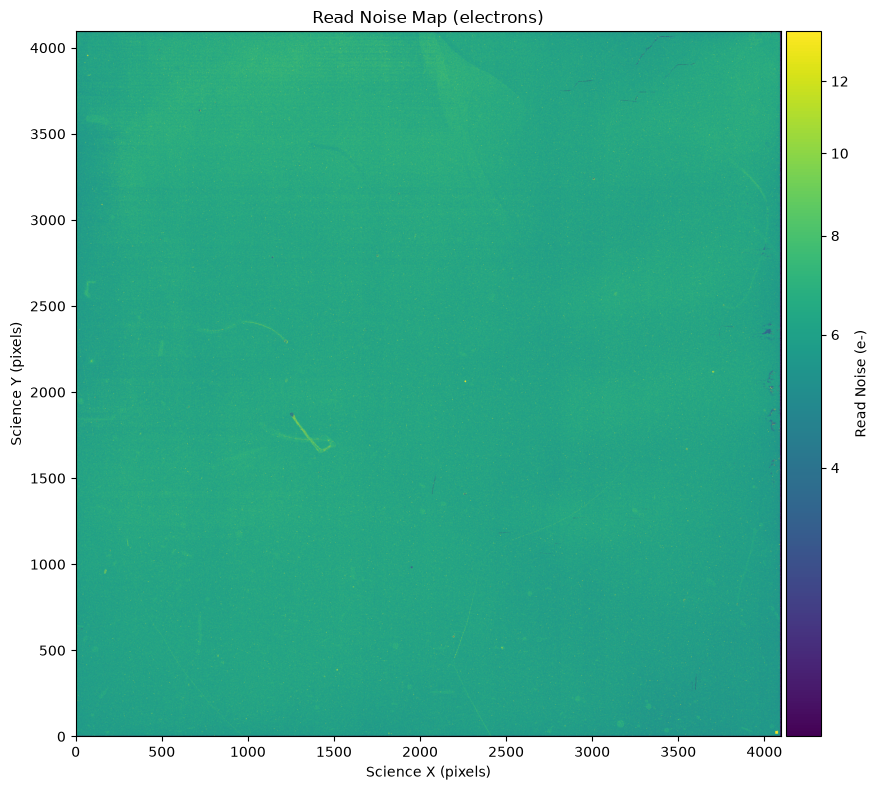

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

my_cmap = copy.copy(cm.get_cmap('viridis'))
my_cmap.set_bad('black')

norm = simple_norm(readnoise.data, stretch='sqrt', percent=99.5)
im = ax.imshow(readnoise.data, cmap=my_cmap, norm=norm, origin='lower')
ax.set_title('Read Noise Map (electrons)')
ax.set_xlabel('Science X (pixels)')
ax.set_ylabel('Science Y (pixels)')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label='Read Noise (e-)')

plt.tight_layout()
plt.show()

## About this Notebook
**Author:** R. Diaz

**Updated On:** 2026-07-06

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>